### Import Packages

In [2]:
import io
import os
import pathlib

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import colors
from skimage.io import imsave, imread
import cv2

from hpacellseg.utils import label_cell, label_nuclei

### Cell Segmentation of a Image 
* HPA Segmentation Tool: https://github.com/CellProfiling/HPA-Cell-Segmentation/tree/master

In [4]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"running on device: {DEVICE}")

running on device: cuda


In [5]:
import collections
collections.Iterable = collections.abc.Iterable

import numpy as np
np.bool = np.bool_

import torch
import torch.nn.functional as F

import cv2
from skimage import transform as sk_transform, util as sk_util

import hpacellseg.cellsegmentator as cellsegmentator

NORMALIZE = {"mean": [124 / 255, 117 / 255, 104 / 255], "std": [1 / (0.0167 * 255)] * 3}

NUC_MODEL = "./nuclei-model.pth"
CELL_MODEL = "./cell-model.pth"


class CellSegmentator(cellsegmentator.CellSegmentator):
    def pred_nuclei(self, images):
        # This first is the version from hpacellseg
        # def _preprocess(image):
        #     if isinstance(image, str):
        #         image = imageio.imread(image)
        #     self.target_shape = image.shape
        #     if len(image.shape) == 2:
        #         image = np.dstack((image, image, image))
        #     image = transform.rescale(image, self.scale_factor, multichannel=True)
        #     nuc_image = np.dstack((image[..., 2], image[..., 2], image[..., 2]))
        #     if self.padding:
        #         rows, cols = nuc_image.shape[:2]
        #         self.scaled_shape = rows, cols
        #         nuc_image = cv2.copyMakeBorder(
        #             nuc_image,
        #             32,
        #             (32 - rows % 32),
        #             32,
        #             (32 - cols % 32),
        #             cv2.BORDER_REFLECT,
        #         )
        #     nuc_image = nuc_image.transpose([2, 0, 1])
        #     return nuc_image

        def _preprocess(image):
            if isinstance(image, str):
                image = imageio.imread(image)
            self.target_shape = image.shape
            if len(image.shape) == 2:
                image = np.dstack((image, image, image))
            image = sk_transform.rescale(image, self.scale_factor, channel_axis=-1)
            nuc_image = np.dstack((image[..., 2], image[..., 2], image[..., 2]))
            if self.padding:
                rows, cols = nuc_image.shape[:2]
                self.scaled_shape = rows, cols
                nuc_image = cv2.copyMakeBorder(
                    nuc_image,
                    32,
                    (32 - rows % 32),
                    32,
                    (32 - cols % 32),
                    cv2.BORDER_REFLECT,
                )
            nuc_image = nuc_image.transpose([2, 0, 1])
            return nuc_image
        
        # This first is the version from hpacellseg
        # def _segment_helper(imgs):
        #     with torch.no_grad():
        #         mean = torch.as_tensor(NORMALIZE["mean"], device=self.device)
        #         std = torch.as_tensor(NORMALIZE["std"], device=self.device)
        #         imgs = torch.tensor(np.array(imgs)).float()
        #         imgs = imgs.to(self.device)
        #         imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])
        #         imgs = self.nuclei_model(imgs)
        #         imgs = F.softmax(imgs, dim=1)
        #         return imgs

        # preprocessed_imgs = map(_preprocess, images)
        # predictions = map(lambda x: _segment_helper([x]), preprocessed_imgs)
        # predictions = map(lambda x: x.to("cpu").numpy()[0], predictions)
        # predictions = map(util.img_as_ubyte, predictions)
        # predictions = list(map(self._restore_scaling_padding, predictions))
        # return predictions

        def _segment_helper(imgs):
            with torch.no_grad():
                mean = torch.as_tensor(NORMALIZE["mean"], device=self.device)
                std = torch.as_tensor(NORMALIZE["std"], device=self.device)
                imgs = torch.tensor(np.array(imgs)).float()
                imgs = imgs.to(self.device)
                imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])
                imgs = self.nuclei_model(imgs)
                imgs = F.softmax(imgs, dim=1)
                return imgs

        preprocessed_imgs = map(_preprocess, images)
        predictions = map(lambda x: _segment_helper([x]), preprocessed_imgs)
        predictions = map(lambda x: x.to("cpu").numpy()[0], predictions)
        predictions = map(sk_util.img_as_ubyte, predictions)
        predictions = list(map(self._restore_scaling_padding, predictions))
        return predictions

    def pred_cells(self, images, precombined=False):
        # This first is the version from hpacellseg
        # def _preprocess(image):
        #     self.target_shape = image.shape
        #     if not len(image.shape) == 3:
        #         raise ValueError("image should has 3 channels")
        #     cell_image = transform.rescale(image, self.scale_factor, multichannel=True)
        #     if self.padding:
        #         rows, cols = cell_image.shape[:2]
        #         self.scaled_shape = rows, cols
        #         cell_image = cv2.copyMakeBorder(
        #             cell_image,
        #             32,
        #             (32 - rows % 32),
        #             32,
        #             (32 - cols % 32),
        #             cv2.BORDER_REFLECT,
        #         )
        #     cell_image = cell_image.transpose([2, 0, 1])
        #     return cell_image

        # def _segment_helper(imgs):
        #     with torch.no_grad():
        #         mean = torch.as_tensor(NORMALIZE["mean"], device=self.device)
        #         std = torch.as_tensor(NORMALIZE["std"], device=self.device)
        #         imgs = torch.tensor(np.array(imgs)).float()
        #         imgs = imgs.to(self.device)
        #         imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])

        #         imgs = self.cell_model(imgs)
        #         imgs = F.softmax(imgs, dim=1)
        #         return imgs

        # if not precombined:
        #     images = self._image_conversion(images)
        # preprocessed_imgs = map(_preprocess, images)
        # predictions = map(lambda x: _segment_helper([x]), preprocessed_imgs)
        # predictions = map(lambda x: x.to("cpu").numpy()[0], predictions)
        # predictions = map(self._restore_scaling_padding, predictions)
        # predictions = list(map(util.img_as_ubyte, predictions))

        def _preprocess(image):
            self.target_shape = image.shape
            if not len(image.shape) == 3:
                raise ValueError("image should has 3 channels")
            cell_image = sk_transform.rescale(image, self.scale_factor, channel_axis=-1)
            if self.padding:
                rows, cols = cell_image.shape[:2]
                self.scaled_shape = rows, cols
                cell_image = cv2.copyMakeBorder(
                    cell_image,
                    32,
                    (32 - rows % 32),
                    32,
                    (32 - cols % 32),
                    cv2.BORDER_REFLECT,
                )
            cell_image = cell_image.transpose([2, 0, 1])
            return cell_image

        def _segment_helper(imgs):
            with torch.no_grad():
                mean = torch.as_tensor(NORMALIZE["mean"], device=self.device)
                std = torch.as_tensor(NORMALIZE["std"], device=self.device)
                imgs = torch.tensor(np.array(imgs)).float()
                imgs = imgs.to(self.device)
                imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])

                imgs = self.cell_model(imgs)
                imgs = F.softmax(imgs, dim=1)
                return imgs

        if not precombined:
            images = self._image_conversion(images)
        preprocessed_imgs = map(_preprocess, images)
        predictions = map(lambda x: _segment_helper([x]), preprocessed_imgs)
        predictions = map(lambda x: x.to("cpu").numpy()[0], predictions)
        predictions = map(self._restore_scaling_padding, predictions)
        predictions = list(map(sk_util.img_as_ubyte, predictions))

        return predictions

In [6]:
segmentator = CellSegmentator(
    NUC_MODEL,
    CELL_MODEL,
    scale_factor=0.25,
    device=DEVICE,
    padding=True,
    multi_channel_model=True,
)

please compile abn


/home/jumidlej/git-projects/.venv/lib/python3.12/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'pytorch_zoo.unet.DPNUnet' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/jumidlej/git-projects/.venv/lib/python3.12/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/jumidlej/git-projects/.venv/lib/python3.12/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve

### Plot a Image with Cell Masks

In [12]:
IMAGES_DIR = "/home/jumidlej/datasets/hpa-single-cell-image-classification/train"
CHANNEL_COLORS = {
    'red': (1, 0, 0, 0.5),
    'green': (0, 1, 0, 0.5),
    'blue': (0, 0, 1, 0.5),
    'orange': (1, 0.6, 0, 0.5)
}

In [17]:
def plot_image(image, labels_names):
    """
    Plota uma imagem com 4 canais do dataset sobreposta em uma única figura,
    garantindo que todas as cores apareçam corretamente.
    
    Args:
        image (np.ndarray): Imagem com 4 canais (altura, largura, canais).
        labels_names (str): Nomes dos rótulos para exibir no título da imagem.
    """

    fig, ax = plt.subplots(figsize=(5, 5))

    # Resize image to 512x512
    # image = cv2.resize(image, (512, 512))
    
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
    for i, (channel_name, color) in enumerate(CHANNEL_COLORS.items()):
        channel_image = image[:, :, i]
        channel_image = channel_image.astype(np.float32)
        channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
        
        for j in range(3):
            combined_image[:, :, j] += channel_image * color[j]
    combined_image = np.clip(combined_image, 0, 1)
    
    ax.imshow(combined_image)
    ax.axis('off')
    plt.show()

def plot_mask(mask):
    """
    Exibe uma máscara onde o valor 0 é preto (fundo)
    e cada número > 0 tem uma cor diferente.
    """
    mask = np.array(mask).astype(int)
    num_classes = mask.max() + 1

    # Cria um colormap baseado no 'tab20'
    base_cmap = plt.cm.get_cmap('tab20', num_classes)
    cmap_colors = base_cmap(np.arange(num_classes))

    # Define o valor 0 como preto
    cmap_colors[0] = np.array([0, 0, 0, 1])  # RGBA
    cmap_colors[-1] = np.array([0.6, 0.1, 0.6, 1])  # Última cor azul

    # Cria um novo colormap com essa modificação
    custom_cmap = colors.ListedColormap(cmap_colors)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(mask, cmap=custom_cmap, vmin=0, vmax=num_classes-1)

    cbar = plt.colorbar(im, ax=ax, ticks=range(num_classes))
    cbar.ax.set_yticklabels(range(num_classes))

    plt.axis('off')
    plt.show()

In [18]:
def get_image(images_dir, sample_id):
    colors = ('red','green','blue','yellow')
    images = [cv2.imread(os.path.join(images_dir, f'{sample_id}_{c}.png'), cv2.IMREAD_GRAYSCALE) for c in colors]
    image = np.stack(images, axis=-1)
    if image.dtype == np.uint16:
        image = ((image.astype("float32")/65536.)*255.).astype("uint8")
    return image

def combine_channels(image):
    """Combina os 4 canais coloridos em uma imagem RGB."""
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
    for i, (channel_name, color) in enumerate(CHANNEL_COLORS.items()):
        channel_image = image[:, :, i].astype(np.float32)
        channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
        for j in range(3):
            combined_image[:, :, j] += channel_image * color[j]
    combined_image = np.clip(combined_image, 0, 1)
    return combined_image

def overlay_mask(image, mask, alpha=0.4):
    """
    Sobrepõe a máscara instancial na imagem original.
    
    Args:
        image (np.ndarray): Imagem RGB normalizada entre [0,1].
        mask (np.ndarray): Máscara com inteiros representando instâncias.
        alpha (float): Grau de transparência da máscara.
    """
    mask = np.array(mask).astype(int)
    num_classes = mask.max() + 1

    # Cria colormap (classe 0 = preta / transparente)
    base_cmap = plt.cm.get_cmap('tab20', num_classes)
    cmap_colors = base_cmap(np.arange(num_classes))
    cmap_colors[0] = np.array([0, 0, 0, 0])  # fundo totalmente transparente
    cmap_colors[-1] = np.array([0.6, 0.1, 0.6, 1])  # Última cor azul
    cmap = colors.ListedColormap(cmap_colors)

    # Normaliza máscara para o colormap
    mask_rgb = cmap(mask)[..., :3]

    # Cria blend entre imagem e máscara
    blended = (1 - alpha) * image + alpha * mask_rgb
    blended = np.clip(blended, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(blended)
    plt.axis('off')
    plt.show()

/tmp/ipykernel_1718/362224811.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('tab20', num_classes)


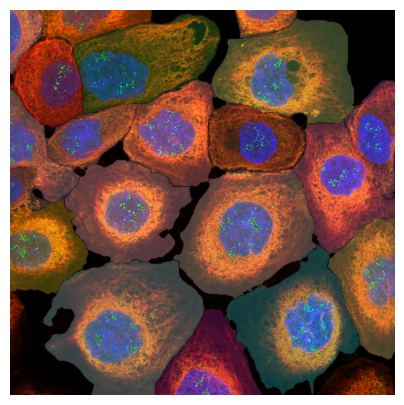

In [15]:
image = get_image(IMAGES_DIR, 'd0c1b088-bbca-11e8-b2bc-ac1f6b6435d0')
rgb_image = combine_channels(image)

nuclei_seg = segmentator.pred_nuclei([image[..., 2]])
cell_seg = segmentator.pred_cells([image[..., [0, 3, 2]]], precombined=True)
nuclei_mask, cell_mask = label_cell(nuclei_seg[0], cell_seg[0])

overlay_mask(rgb_image, cell_mask, alpha=0.3)

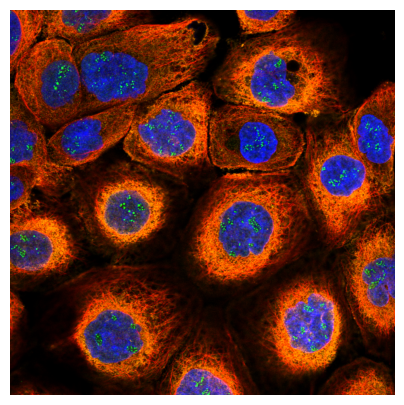

Nuclei mask shape: (2048, 2048) dtype: uint16
Cell mask shape: (2048, 2048) dtype: uint16


/tmp/ipykernel_1718/2367242852.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('tab20', num_classes)


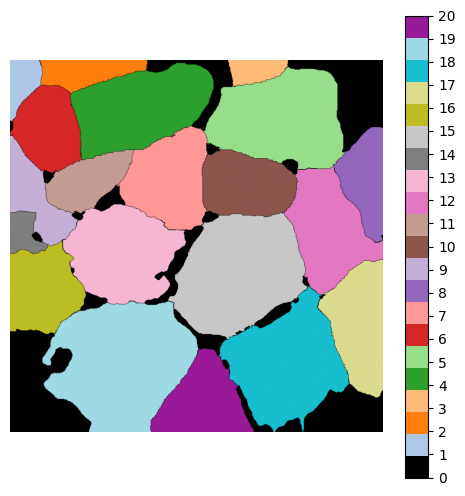

In [19]:
image = get_image(IMAGES_DIR, 'd0c1b088-bbca-11e8-b2bc-ac1f6b6435d0')
plot_image(image, "")

nuclei_seg = segmentator.pred_nuclei([image[..., 2]])  # blue channel for nuclei
cell_seg = segmentator.pred_cells([image[..., [0, 3, 2]]], precombined=True) # order: microtubules, ER, nuclei R Y B
nuclei_mask, cell_mask = label_cell(nuclei_seg[0], cell_seg[0])

print("Nuclei mask shape:", nuclei_mask.shape, "dtype:", nuclei_mask.dtype)
print("Cell mask shape:", cell_mask.shape, "dtype:", cell_mask.dtype)

plot_mask(cell_mask)

### 2nd Segmentated Images

In [ ]:
# Pegar imagens do segundo lugar e colocar aqui uma do lado da outra bonitinhas.
dir = "/home/jumidlej/datasets/input/train_cell_256/"
df = "/home/jumidlej/git-projects/hpa-individual-cell-classifier/datasets/split/256_train+ext+rare.csv"
df = pd.read_csv(df)

def get_cell_images(images_dir, sample_id, n_cells):
    images = [
        cv2.imread(
            os.path.join(images_dir, f'{sample_id}_{c}.png'), cv2.IMREAD_UNCHANGED
        ) for c in range(1, n_cells+1)]
    return images

def plot_image(image, labels_names):
    """
    Plota uma imagem com 4 canais do dataset sobreposta em uma única figura,
    garantindo que todas as cores apareçam corretamente.
    
    Args:
        image (np.ndarray): Imagem com 4 canais (altura, largura, canais).
        labels_names (str): Nomes dos rótulos para exibir no título da imagem.
    """

    fig, ax = plt.subplots(figsize=(4, 4))

    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
    for i, (channel_name, color) in enumerate(CHANNEL_COLORS.items()):
        channel_image = image[:, :, i]
        channel_image = channel_image.astype(np.float32)
        channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
        
        for j in range(3):
            combined_image[:, :, j] += channel_image * color[j]
    combined_image = np.clip(combined_image, 0, 1)
    
    ax.imshow(combined_image)
    ax.axis('off')
    plt.title(labels_names, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_images_row(images, labels_list, channel_colors):
    """
    Plota várias imagens HPA lado a lado, cada uma com seus rótulos.
    
    Args:
        images (list[np.ndarray]): Lista de imagens com 4 canais (H, W, C).
        labels_list (list[list[str]]): Lista de listas com os nomes dos rótulos de cada imagem.
        channel_colors (dict): Dicionário de cores por canal (como CHANNEL_COLORS).
    
    """

    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    # Se for só uma imagem, axes não é lista — precisa padronizar
    if n == 1:
        axes = [axes]

    for idx, (image, labels_names, ax) in enumerate(zip(images, labels_list, axes)):
        # Cria imagem combinada
        combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
        for i, (channel_name, color) in enumerate(channel_colors.items()):
            channel_image = image[:, :, i].astype(np.float32)
            channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
            for j in range(3):
                combined_image[:, :, j] += channel_image * color[j]
        combined_image = np.clip(combined_image, 0, 1)

        ax.imshow(combined_image)
        ax.axis("off")
        ax.set_title(", ".join(labels_names), fontsize=12)

    plt.tight_layout()
    plt.show()

In [18]:
df.columns

Index(['ID', 'class0', 'class1', 'class2', 'class3', 'class4', 'class5',
       'class6', 'class7', 'class8', 'class9', 'class10', 'class11', 'class12',
       'class13', 'class14', 'class15', 'class16', 'class17', 'class18',
       'fold', 'idx'],
      dtype='object')

In [37]:
import random

# Escolhe uma amostra aleatória
row = df.iloc[1]

sample_id = row["ID"]
n_cells = 6

print("Sample ID:", sample_id)
print("N cells:", n_cells)

Sample ID: 5fb643ee-bb99-11e8-b2b9-ac1f6b6435d0
N cells: 6


In [38]:
images = get_cell_images(
    images_dir=dir,
    sample_id=sample_id,
    n_cells=n_cells,
)

print(f"Loaded {len(images)} cell images")


Loaded 6 cell images


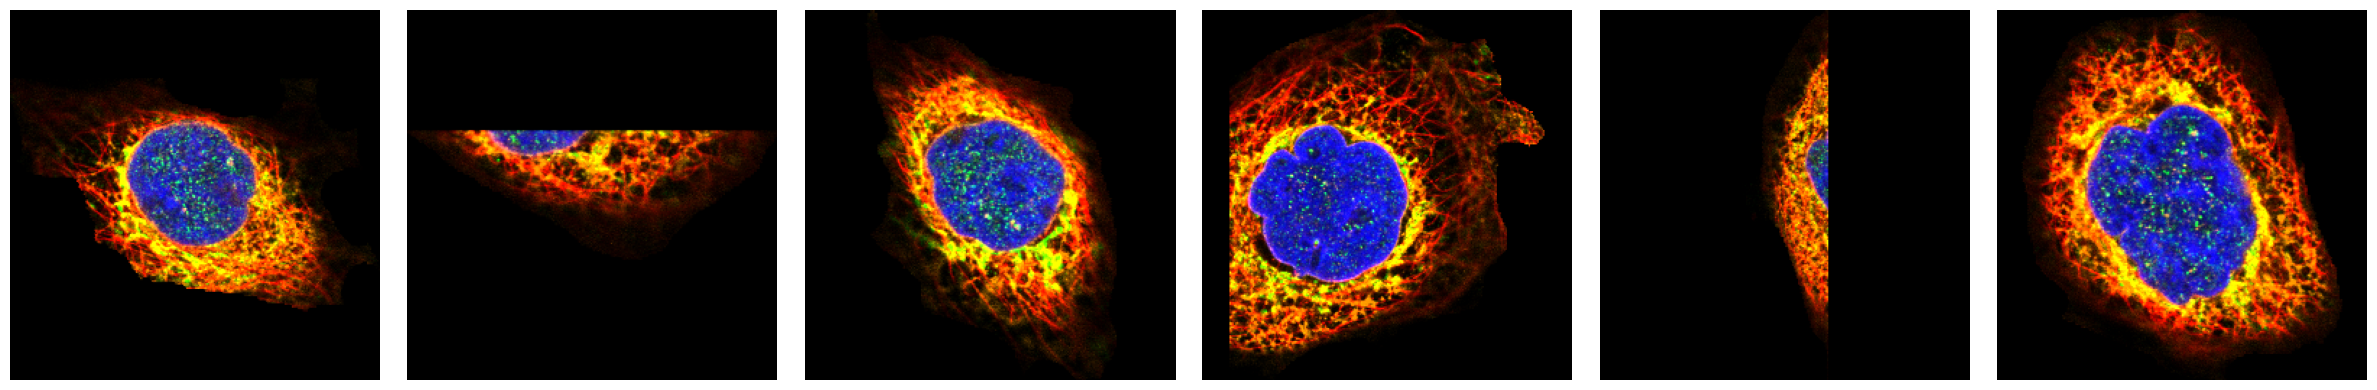

In [39]:
CHANNEL_COLORS = {
    'blue': (0, 0, 1, 0.5),   # azul com alpha 0.5
    'green': (0, 1, 0, 0),  # verde com alpha 0.5
    'red': (1, 0, 0, 0.5),    # vermelho com alpha 0.5
    'orange': (1, 0.6, 0, 0.5) # laranja com alpha 0.5
}

plot_images_row(
    images=images,
    labels_list=[""] * 6,
    channel_colors=CHANNEL_COLORS
)


### Four Channels of a Image from Kaggle

In [60]:
# Pegar imagens do segundo lugar e colocar aqui uma do lado da outra bonitinhas.
dir = "/home/jumidlej/datasets/hpa-single-cell-image-classification/train/"
df = "/home/jumidlej/datasets/hpa-single-cell-image-classification/train.csv"
df = pd.read_csv(df)

def get_image(images_dir, sample_id):
    colors = ('red','green','blue','yellow')
    images = [cv2.imread(os.path.join(images_dir, f'{sample_id}_{c}.png'), cv2.IMREAD_GRAYSCALE) for c in colors]
    image = np.stack(images, axis=-1)
    if image.dtype == np.uint16:
        image = ((image.astype("float32")/65536.)*255.).astype("uint8")
    return image

def plot_image(image, labels_names):
    """
    Plota uma imagem com 4 canais do dataset sobreposta em uma única figura,
    garantindo que todas as cores apareçam corretamente.
    
    Args:
        image (np.ndarray): Imagem com 4 canais (altura, largura, canais).
        labels_names (str): Nomes dos rótulos para exibir no título da imagem.
    """
    CHANNEL_COLORS = {
        'red': (1, 0, 0, 0.5),    # vermelho com alpha 0.5
        'green': (0, 1, 0, 0),  # verde com alpha 0.5
        'blue': (0, 0, 1, 0.5),   # azul com alpha 0.5
        'orange': (1, 0.6, 0, 0.5) # laranja com alpha 0.5
    }
    fig, ax = plt.subplots(figsize=(4, 4))

    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
    for i, (channel_name, color) in enumerate(CHANNEL_COLORS.items()):
        channel_image = image[:, :, i]
        channel_image = channel_image.astype(np.float32)
        channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
        
        for j in range(3):
            combined_image[:, :, j] += channel_image * color[j]
    combined_image = np.clip(combined_image, 0, 1)
    
    ax.imshow(combined_image)
    ax.axis('off')
    plt.title(labels_names, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_images_row(images, labels_list, channel_colors):
    """
    Plota várias imagens HPA lado a lado, cada uma com seus rótulos.
    
    Args:
        images (list[np.ndarray]): Lista de imagens com 4 canais (H, W, C).
        labels_list (list[list[str]]): Lista de listas com os nomes dos rótulos de cada imagem.
        channel_colors (dict): Dicionário de cores por canal (como CHANNEL_COLORS).
    
    """

    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    # Se for só uma imagem, axes não é lista — precisa padronizar
    if n == 1:
        axes = [axes]

    for idx, (image, labels_names, ax) in enumerate(zip(images, labels_list, axes)):
        # Cria imagem combinada
        combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
        for i, (channel_name, color) in enumerate(channel_colors.items()):
            channel_image = image[:, :, i].astype(np.float32)
            channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
            for j in range(3):
                combined_image[:, :, j] += channel_image * color[j]
        combined_image = np.clip(combined_image, 0, 1)

        ax.imshow(combined_image)
        ax.axis("off")
        ax.set_title(", ".join(labels_names), fontsize=12)

    plt.tight_layout()
    plt.show()

In [82]:
def create_colormap(color):
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list('custom_cmap', ['black', color])

def plot_image_with_4_channels(image):
    """
    Plota uma imagem com 4 canais do dataset em subplots.
    
    Args:
        dataset: O dataset que contém as imagens.
        index: O índice da amostra da qual a imagem deve ser extraída.
    """
    # Verifica se a imagem tem 4 canais
    assert image.shape[2] == 4, "A imagem deve ter 4 canais."
    
    # Configura a figura com 4 subplots
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    
    # Nomes dos canais para os títulos
    channel_names = ['red', 'green', 'blue', 'orange']
    text_names = ['(c) Microtúbulos', '(a) Proteína de interesse', '(b) Núcleo', '(d) Retículo endoplasmático']
    
    c = 0
    for i in [1, 2, 0, 3]:
        axs[c].imshow(image[:, :, i], cmap=create_colormap(channel_names[i]), vmin=0, vmax=255)
        # axs[i].set_title(text_names[i], fontsize=12)
        axs[c].set_xlabel(text_names[i], fontsize=16)
        # axs[i].axis('off')  # Remove os eixos
        axs[c].set_xticks([])
        axs[c].set_yticks([])
        for spine in axs[c].spines.values():
            spine.set_visible(False)
        c += 1
    
    # Ajusta o layout
    plt.tight_layout()
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the f

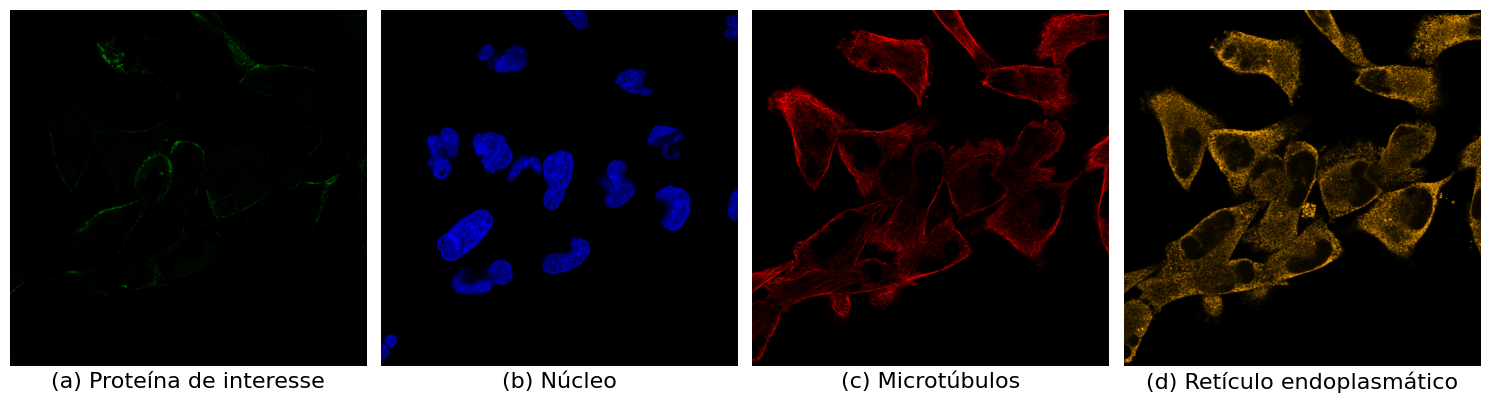

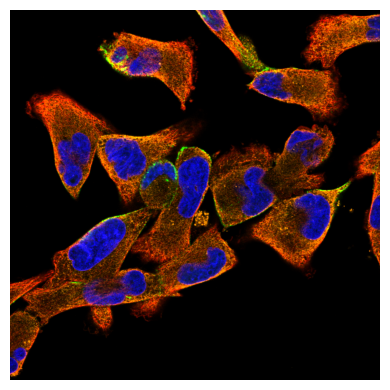

In [83]:
# import matplotlib as mpl

# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = ['CMU Serif']

image = df['ID'].iloc[18]
image = get_image(images_dir=dir, sample_id=image)
# print(type(image))
# print(image.shape)
plot_image_with_4_channels(image)
plot_image(image, "")
